# Explore here

In [95]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

In [96]:
COUNTRIES = ["ESP", "FRA", "DEU", "USA", "BRA"]

INDICATORS = {
    "gdp_per_capita": "NY.GDP.PCAP.CD",
    "population": "SP.POP.TOTL",
    "life_expectancy": "SP.DYN.LE00.IN",
    "renewable_energy": "EG.FEC.RNEW.ZS"
}

API_URL = "https://api.worldbank.org/v2"

def build_http_session(
    retries=5,
    backoff_factor=0.5,
    status_forcelist=(429, 500, 502, 503, 504),
):
    session = requests.Session()

    retry = Retry(
        total=retries,
        connect=retries,
        read=retries,
        backoff_factor=backoff_factor,
        status_forcelist=status_forcelist,
        allowed_methods=["GET"],
    )

    adapter = HTTPAdapter(max_retries=retry)
    session.mount("https://", adapter)
    session.mount("http://", adapter)

    return session

session = build_http_session()

In [97]:
REQUEST_TIMEOUT = 60

def download_indicator(indicator_code, countries, start=2010, end=2024):
    country_segment = ";".join(countries)

    endpoint = f"{API_URL}/country/{country_segment}/indicator/{indicator_code}"

    results = []
    page = 1

    while True:
        params = {
            "format": "json",
            "date": f"{start}:{end}",
            "per_page": 50,
            "page": page,
        }

        response = session.get(endpoint, params=params, timeout=REQUEST_TIMEOUT)

        # 🔥 IMPORTANTE: no romper todo si hay error
        if response.status_code != 200:
            print(f"Error {response.status_code} en {indicator_code}")
            break

        payload = response.json()

        if not isinstance(payload, list) or len(payload) < 2:
            break

        meta, data = payload

        if not data:
            break

        results.extend(data)

        if page >= meta.get("pages", 1):
            break

        page += 1

    return results

In [98]:
def build_dataframe(raw_data):
    records = []

    for row in raw_data:
        # protección contra filas incompletas
        if not row:
            continue

        country = row.get("country", {})
        country_name = country.get("value")
        iso3 = row.get("countryiso3code")
        year = row.get("date")
        value = row.get("value")

        if not country_name or not year:
            continue

        records.append({
            "country": country_name,
            "iso3": iso3,
            "year": year,
            "value": value,
        })

    df = pd.DataFrame(records)

    if df.empty:
        return df

    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    df = df.dropna(subset=["year", "value"])
    df["year"] = df["year"].astype(int)

    return df.sort_values(["country", "year"]).reset_index(drop=True)

In [99]:
raw = download_indicator("NY.GDP.PCAP.CD", COUNTRIES)
print(len(raw))
print(raw[:2])

75
[{'indicator': {'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per capita (current US$)'}, 'country': {'id': 'BR', 'value': 'Brazil'}, 'countryiso3code': 'BRA', 'date': '2024', 'value': 10310.5488778166, 'unit': '', 'obs_status': '', 'decimal': 1}, {'indicator': {'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per capita (current US$)'}, 'country': {'id': 'BR', 'value': 'Brazil'}, 'countryiso3code': 'BRA', 'date': '2023', 'value': 10377.5897719195, 'unit': '', 'obs_status': '', 'decimal': 1}]


In [100]:
datasets = {}

for name, code in INDICATORS.items():
    raw = download_indicator(code, COUNTRIES)
    datasets[name] = build_dataframe(raw)

datasets["gdp_per_capita"].head()

,country,iso3,year,value
0,Brazil,BRA,2010,11403.284004
1,Brazil,BRA,2011,13396.626316
2,Brazil,BRA,2012,12521.723845
3,Brazil,BRA,2013,12458.890340
4,Brazil,BRA,2014,12274.994163


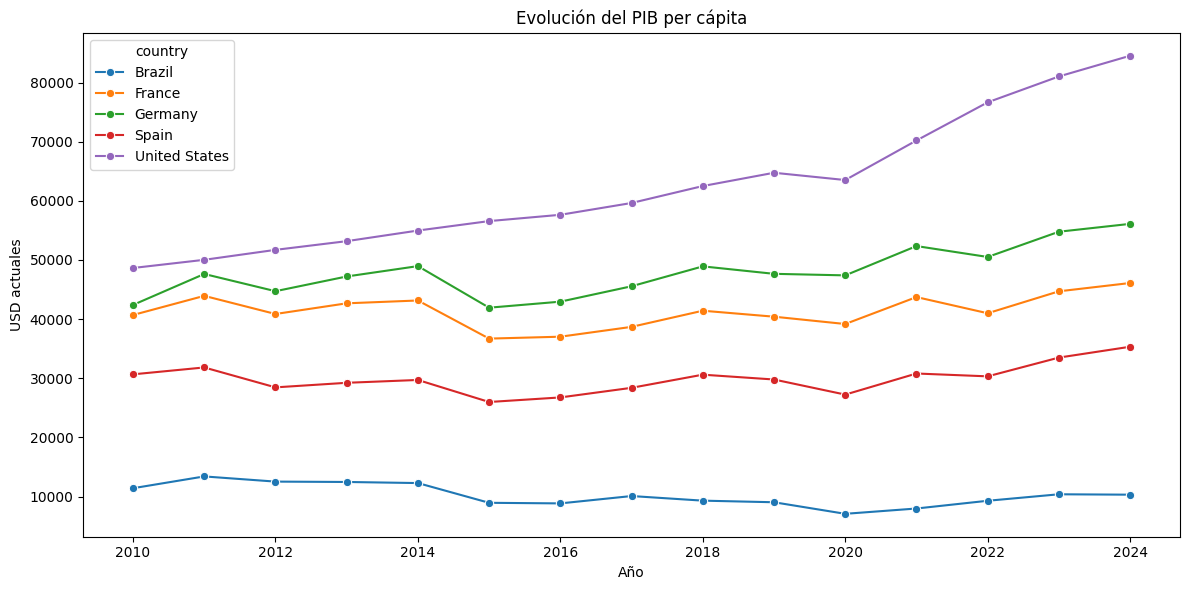

In [101]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=datasets["gdp_per_capita"],
    x="year",
    y="value",
    hue="country",
    marker="o",
)

plt.title("Evolución del PIB per cápita")
plt.xlabel("Año")
plt.ylabel("USD actuales")
plt.tight_layout()
plt.show()

Año usado: 2021


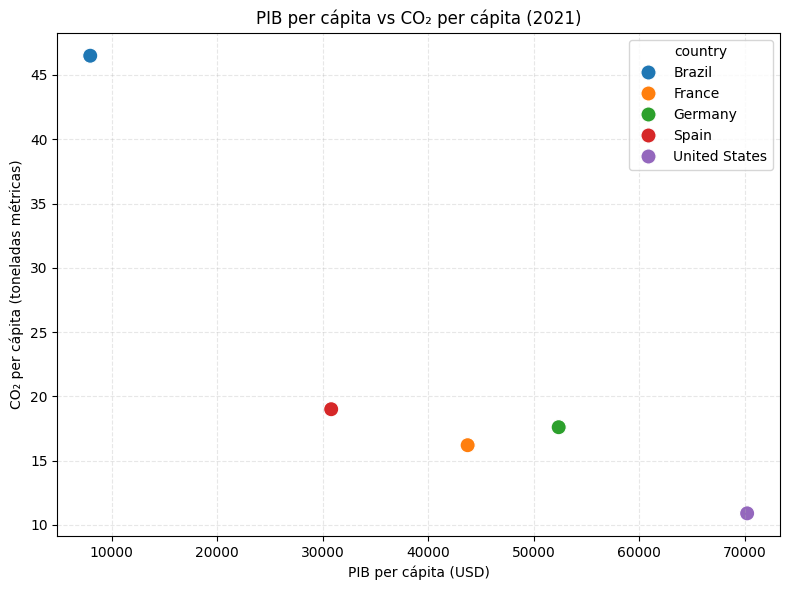

In [103]:
# ---------------------------------------------------------
# Scatter: PIB per cápita vs CO2 per cápita
# ---------------------------------------------------------

target_year = min(
    datasets["gdp_per_capita"]["year"].max(),
    datasets["renewable_energy"]["year"].max()
)

print("Año usado:", target_year)

# Tomamos los DataFrames
gdp_df = datasets.get("gdp_per_capita")
co2_df = datasets.get("renewable_energy")

# Validación defensiva
if gdp_df is None or co2_df is None:
    print("No existen los datasets necesarios.")
elif gdp_df.empty or co2_df.empty:
    print("Alguno de los datasets está vacío.")
elif "year" not in gdp_df.columns or "year" not in co2_df.columns:
    print("Falta la columna 'year' en alguno de los datasets.")
else:
    # Filtrado por año (evita usar query)
    gdp_yr = gdp_df[gdp_df["year"] == target_year]
    co2_yr = co2_df[co2_df["year"] == target_year]

    if gdp_yr.empty or co2_yr.empty:
        print(f"⚠️ No hay datos para el año {target_year}.")
    else:
        # Merge por país
        comparison = pd.merge(
            gdp_yr[["country", "value"]],
            co2_yr[["country", "value"]],
            on="country",
            suffixes=("_gdp", "_co2"),
        )

        # Visualización
        plt.figure(figsize=(8, 6))
        sns.scatterplot(
            data=comparison,
            x="value_gdp",
            y="value_co2",
            hue="country",
            s=120,
        )

        plt.title(f"PIB per cápita vs CO₂ per cápita ({target_year})")
        plt.xlabel("PIB per cápita (USD)")
        plt.ylabel("CO₂ per cápita (toneladas métricas)")
        plt.grid(True, linestyle="--", alpha=0.3)
        plt.tight_layout()
        plt.show()

In [104]:
engine = create_engine("sqlite:///world_bank_analysis.db")

for name, df in datasets.items():
    df.to_sql(f"indicator_{name}", engine, if_exists="replace", index=False)

pd.read_sql("SELECT * FROM indicator_gdp_per_capita LIMIT 5", engine)

,country,iso3,year,value
0,Brazil,BRA,2010,11403.284004
1,Brazil,BRA,2011,13396.626316
2,Brazil,BRA,2012,12521.723845
3,Brazil,BRA,2013,12458.890340
4,Brazil,BRA,2014,12274.994163


### CONCLUSIONS 

- GDP per capita shows clear differences in economic development between countries, with the United States and Germany consistently leading, while Brazil remains at lower levels across the period analyzed.

- Most countries display a general upward trend in GDP per capita from 2010 to 2024, although the growth rate varies significantly depending on the country and economic context.

- Life expectancy has improved steadily in all selected countries, suggesting overall progress in healthcare systems and living conditions over time.

- Renewable energy consumption shows higher variability between countries, with European economies generally presenting higher adoption levels compared to the United States and Brazil.

- The relationship between economic development (GDP per capita) and renewable energy usage is not strictly linear, indicating that higher income does not always directly translate into higher renewable energy adoption.

- Overall, the dataset highlights clear disparities in economic, social, and environmental indicators across countries, reinforcing the importance of analyzing multiple dimensions to understand development patterns.